# Advanced Defect Detection: Circle (Hole) + Crack Line Tracking

(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

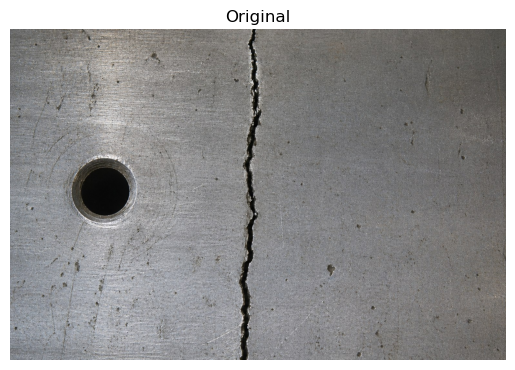

In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("IMAGE 2026-04-29 11:11:15.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

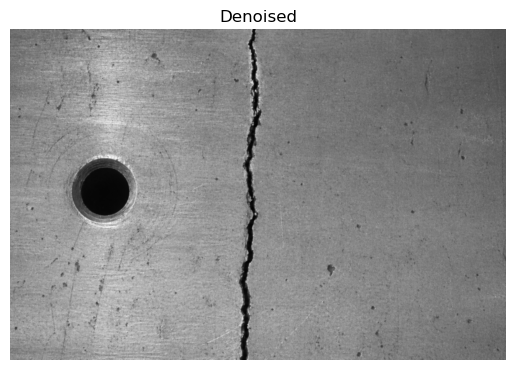

In [2]:

# Grayscale + Denoise
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap='gray')
plt.title("Denoised")
plt.axis('off')


In [3]:

# --- HOLE DETECTION (Hough Circle) ---
circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=20,
    maxRadius=100
)

result = img_rgb.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))
    for c in circles[0, :]:
        cv2.circle(result, (c[0], c[1]), c[2], (0,255,0), 3)  # green circle


In [4]:

# --- CRACK DETECTION (Thin Line Extraction) ---
edges = cv2.Canny(blur, 50, 150)

# Dilate then skeleton-like thinning effect
kernel = np.ones((3,3), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)

# Find contours of crack
contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 200:
        continue

    # Draw crack as RED polyline (not box!)
    cv2.drawContours(result, [cnt], -1, (255,0,0), 2)


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

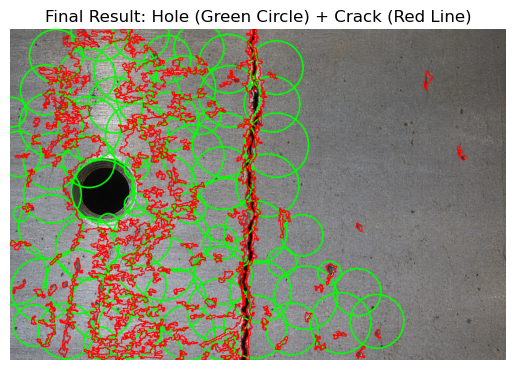

In [5]:

plt.imshow(result)
plt.title("Final Result: Hole (Green Circle) + Crack (Red Line)")
plt.axis('off')
